# eHMM-Guided Transformer for Electricity Demand Forecasting

 lookback=168h | horizon=24h | K=3 states | M=5 ensemble

In [1]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"

for d in [DATA_RAW, DATA_PROCESSED, FIG_DIR, MODEL_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG = {
    "top_n_meters": 1,
    "train_ratio": 0.70,
    "val_ratio": 0.10,
    "test_ratio": 0.20,
    "input_window": 168,
    "forecast_horizon": 24,
    "n_states": 3,
    "n_ensemble": 5,
    "d_model": 128,
    "n_heads": 8,
    "num_layers": 3,
    "dim_feedforward": 256,
    "dropout": 0.1,
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 50,
    "patience": 10,
    "grad_clip": 1.0,
}

print(f"Device: {DEVICE}")
print(f"Root: {ROOT}")

Device: mps
Root: /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting


## Phase 1: Dataset Pipeline

In [2]:
import sys

DATA_FILES = ("demand.parquet", "metadata.parquet", "weather.parquet")


def resolve_data_paths(raw_dir: Path) -> dict[str, Path]:
    """Resolve parquet paths (supports data/raw/ and data/raw/data/)."""
    paths = {}
    for name in DATA_FILES:
        direct = raw_dir / name
        nested = raw_dir / "data" / name
        if direct.exists():
            paths[name] = direct
        elif nested.exists():
            paths[name] = nested
        else:
            paths[name] = direct
    return paths


def ensure_dataset(raw_dir: Path) -> dict[str, Path]:
    paths = resolve_data_paths(raw_dir)
    if all(p.exists() for p in paths.values()):
        return paths

    print("Dataset chua co. Dang thu download tu Hugging Face...")
    import subprocess

    result = subprocess.run(
        [sys.executable, str(ROOT / "scripts" / "download_data.py")],
        cwd=ROOT,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise FileNotFoundError(
            "Khong tai duoc dataset.\n"
            "Buoc 1: https://huggingface.co/datasets/EDS-lab/electricity-demand -> Accept terms\n"
            "Buoc 2: hf auth login\n"
            "Buoc 3: python scripts/download_data.py"
        )

    paths = resolve_data_paths(raw_dir)
    missing = [p for p in paths.values() if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Van thieu file: {missing}")
    return paths


data_paths = ensure_dataset(DATA_RAW)
demand = pd.read_parquet(data_paths["demand.parquet"])
metadata = pd.read_parquet(data_paths["metadata.parquet"])
weather = pd.read_parquet(data_paths["weather.parquet"])

print(demand.shape, metadata.shape, weather.shape)
demand.head()

(237944171, 3) (7572, 11) (604848, 33)


,unique_id,timestamp,y
0,a4077c2f0ac5f939,2012-10-12 00:30:00,0.0
1,a4077c2f0ac5f939,2012-10-12 01:00:00,0.0
2,a4077c2f0ac5f939,2012-10-12 01:30:00,0.0
3,a4077c2f0ac5f939,2012-10-12 02:00:00,0.0
4,a4077c2f0ac5f939,2012-10-12 02:30:00,0.0


In [3]:
def select_top_meters_fast(demand_df, metadata_df, top_n=1):
    """
    Select best meter IDs directly from demand + metadata (no weather join needed).
    Operates on the raw demand table — much faster than filtering after full merge.
    """
    demand_df = demand_df.copy()
    demand_df["timestamp"] = pd.to_datetime(demand_df["timestamp"])

    stats = (
        demand_df.groupby("unique_id")
        .agg(
            n_rows=("y", "count"),
            missing_ratio=("y", lambda s: s.isna().mean()),
            start=("timestamp", "min"),
            end=("timestamp", "max"),
        )
        .reset_index()
    )
    stats["duration_days"] = (stats["end"] - stats["start"]).dt.days
    stats = stats.sort_values(
        ["missing_ratio", "n_rows", "duration_days"],
        ascending=[True, False, False],
    )
    return stats.head(top_n)["unique_id"].tolist()


def merge_datasets(demand_df, metadata_df, weather_df):
    """Merge after demand is already filtered to selected meters."""
    df = demand_df.merge(metadata_df, on="unique_id", how="inner")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    weather_df = weather_df.copy()
    weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])
    df = df.merge(weather_df, on=["location_id", "timestamp"], how="left")
    return df.sort_values(["unique_id", "timestamp"]).reset_index(drop=True)


def resample_hourly(df):
    frames = []
    weather_cols = [
        c for c in df.columns
        if c not in ["unique_id", "timestamp", "y"] and pd.api.types.is_numeric_dtype(df[c])
    ]
    meta_cols = [c for c in df.columns if c not in weather_cols + ["timestamp", "y"]]

    for uid, g in df.groupby("unique_id"):
        g = g.set_index("timestamp").sort_index()
        agg = {"y": "sum"}
        for c in weather_cols:
            agg[c] = "mean"
        hourly = g.resample("1h").agg(agg)
        for c in meta_cols:
            if c != "unique_id":
                hourly[c] = g[c].iloc[0]
        hourly["unique_id"] = uid
        hourly = hourly.reset_index()
        frames.append(hourly)
    return pd.concat(frames, ignore_index=True)


def handle_missing(df, max_gap_hours=6):
    df = df.sort_values(["unique_id", "timestamp"]).copy()
    weather_cols = [
        "temperature_2m", "relative_humidity_2m", "apparent_temperature",
        "precipitation", "rain", "snowfall", "dew_point_2m",
    ]
    weather_cols = [c for c in weather_cols if c in df.columns]

    frames = []
    for uid, g in df.groupby("unique_id"):
        g = g.set_index("timestamp").sort_index()
        full_idx = pd.date_range(g.index.min(), g.index.max(), freq="1h")
        g = g.reindex(full_idx)
        g["unique_id"] = uid

        missing_mask = g["y"].isna()
        if missing_mask.any():
            gap_id = (missing_mask != missing_mask.shift()).cumsum()
            gap_sizes = missing_mask.groupby(gap_id).transform("sum")
            g.loc[gap_sizes > max_gap_hours, "y"] = np.nan
        g["y"] = g["y"].interpolate(method="linear", limit=max_gap_hours)
        g = g.dropna(subset=["y"])

        for c in weather_cols:
            g[c] = g[c].ffill().bfill()
        frames.append(g.reset_index().rename(columns={"index": "timestamp"}))
    return pd.concat(frames, ignore_index=True)


def add_time_features(df):
    df = df.copy()
    ts = df["timestamp"]
    df["hour"] = ts.dt.hour
    df["day_of_week"] = ts.dt.dayofweek
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    return df


def add_lag_rolling_features(df):
    df = df.sort_values(["unique_id", "timestamp"]).copy()
    g = df.groupby("unique_id")["y"]
    df["y_lag_1"] = g.shift(1)
    df["y_lag_24"] = g.shift(24)
    df["y_lag_168"] = g.shift(168)
    df["rolling_mean_24"] = g.transform(lambda s: s.shift(1).rolling(24, min_periods=1).mean())
    df["rolling_std_24"] = g.transform(lambda s: s.shift(1).rolling(24, min_periods=1).std()).fillna(0)
    df["rolling_mean_168"] = g.transform(lambda s: s.shift(1).rolling(168, min_periods=1).mean())
    df["rolling_std_168"] = g.transform(lambda s: s.shift(1).rolling(168, min_periods=1).std()).fillna(0)
    return df.dropna().reset_index(drop=True)


def chronological_split(df, train_ratio=0.7, val_ratio=0.1):
    df = df.sort_values("timestamp").reset_index(drop=True)
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

In [4]:
CACHE_TRAIN = DATA_PROCESSED / "processed_train.parquet"
CACHE_VAL   = DATA_PROCESSED / "processed_val.parquet"
CACHE_TEST  = DATA_PROCESSED / "processed_test.parquet"

if CACHE_TRAIN.exists() and CACHE_VAL.exists() and CACHE_TEST.exists():
    print("Loading cached processed data...")
    train_df = pd.read_parquet(CACHE_TRAIN)
    val_df   = pd.read_parquet(CACHE_VAL)
    test_df  = pd.read_parquet(CACHE_TEST)
    selected_ids = train_df["unique_id"].unique().tolist()
else:
    print("Step 1/6: Selecting best meters (fast, no weather join)...")
    selected_ids = select_top_meters_fast(demand, metadata, top_n=CONFIG["top_n_meters"])
    print(f"  Selected: {selected_ids}")

    print("Step 2/6: Filtering demand to selected meters...")
    demand_sub = demand[demand["unique_id"].isin(selected_ids)].copy()
    print(f"  Demand subset: {len(demand_sub):,} rows")

    print("Step 3/6: Merging with metadata and weather...")
    df = merge_datasets(demand_sub, metadata, weather)
    del demand_sub

    print("Step 4/6: Resample + missing values + features...")
    df = resample_hourly(df)
    df = handle_missing(df)
    df = add_time_features(df)
    df = add_lag_rolling_features(df)

    print("Step 5/6: Chronological split...")
    train_df, val_df, test_df = chronological_split(
        df,
        train_ratio=CONFIG["train_ratio"],
        val_ratio=CONFIG["val_ratio"],
    )

    print("Step 6/6: Saving to cache...")
    train_df.to_parquet(CACHE_TRAIN, index=False)
    val_df.to_parquet(CACHE_VAL, index=False)
    test_df.to_parquet(CACHE_TEST, index=False)

print(f"\nSelected meters: {selected_ids}")
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
train_df.head()

Loading cached processed data...

Selected meters: ['0000402b3d8bb6f6']
Train: 24,427 | Val: 3,490 | Test: 6,980


,timestamp,y,latitude,longitude,cluster_size,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,...,hour_cos,dow_sin,dow_cos,y_lag_1,y_lag_24,y_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168
0,2011-01-08 00:00:00,168.284790,40.29,1.73,1.0,13.5425,86.483841,11.317499,10.479946,0.50,...,1.000000,-0.974928,-0.222521,289.644013,143.689320,61.650485,275.451726,78.408754,255.052782,82.288988
1,2011-01-08 01:00:00,145.954693,40.29,1.73,1.0,13.7175,85.242355,11.267500,10.315918,0.90,...,0.965926,-0.974928,-0.222521,168.284790,123.139159,119.741100,276.476537,76.755021,255.687510,81.192213
2,2011-01-08 02:00:00,141.747573,40.29,1.73,1.0,13.6675,84.851807,11.142500,10.074484,0.80,...,0.866025,-0.974928,-0.222521,145.954693,120.873786,114.239482,277.427184,74.891973,255.843543,80.954230
3,2011-01-08 03:00:00,141.100324,40.29,1.73,1.0,13.5925,86.868904,11.417500,9.353476,1.55,...,0.707107,-0.974928,-0.222521,141.747573,123.948220,115.048544,278.296926,73.094463,256.007282,80.693504
4,2011-01-08 04:00:00,182.362460,40.29,1.73,1.0,13.8425,87.089432,11.692499,9.105686,1.75,...,0.500000,-0.974928,-0.222521,141.100324,157.281553,115.210356,279.011597,71.588054,256.162352,80.445651


## Phase 2: e-HMM Regime Encoder

In [5]:
HMM_FEATURES = [
    "y", "y_lag_24", "rolling_mean_24", "rolling_std_24",
    "temperature_2m", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]
HMM_FEATURES = [c for c in HMM_FEATURES if c in train_df.columns]

REGIME_NAMES = ["regime_low_prob", "regime_normal_prob", "regime_peak_prob"]


class EnsembleHMM:
    def __init__(self, n_models=5, n_states=3, random_state=42):
        self.n_models = n_models
        self.n_states = n_states
        self.random_state = random_state
        self.models = []
        self.scaler = StandardScaler()
        self.state_order = None

    def _fit_single(self, X, seed):
        model = GaussianHMM(
            n_components=self.n_states,
            covariance_type="diag",
            n_iter=200,
            random_state=seed,
        )
        model.fit(X)
        return model

    def fit(self, df, feature_cols, y_col="y", window_size=168):
        X = self.scaler.fit_transform(df[feature_cols].values)
        self.models = []
        rng = np.random.RandomState(self.random_state)

        n_windows = max(1, len(X) - window_size + 1)
        for i in range(self.n_models):
            # Bootstrap by sampling contiguous sub-sequences to preserve temporal structure
            chosen = rng.choice(n_windows, size=n_windows, replace=True)
            X_boot = np.concatenate([X[j : j + window_size] for j in chosen], axis=0)
            model = self._fit_single(X_boot, seed=self.random_state + i)
            self.models.append(model)

        posteriors = self._ensemble_posteriors(X)
        hard = posteriors.argmax(axis=1)
        state_means = []
        for s in range(self.n_states):
            mask = hard == s
            state_means.append(df.loc[mask, y_col].mean() if mask.any() else np.inf)
        self.state_order = np.argsort(state_means)
        return self

    def _ensemble_posteriors(self, X):
        probs = []
        for model in self.models:
            p = model.predict_proba(X)
            probs.append(p)
        return np.mean(probs, axis=0)
    
    def _reorder_probs(self, probs):
        return probs[:, self.state_order]

    def predict_proba(self, df, feature_cols):
        X = self.scaler.transform(df[feature_cols].values)
        probs = self._ensemble_posteriors(X)
        return self._reorder_probs(probs)

    def append_regime_probs(self, df, feature_cols):
        out = df.copy()
        probs = self.predict_proba(out, feature_cols)
        out["regime_low_prob"] = probs[:, 0]
        out["regime_normal_prob"] = probs[:, 1]
        out["regime_peak_prob"] = probs[:, 2]
        out["regime_hard_label"] = probs.argmax(axis=1)
        return out


ehmm = EnsembleHMM(
    n_models=CONFIG["n_ensemble"],
    n_states=CONFIG["n_states"],
    random_state=SEED,
)
ehmm.fit(train_df, HMM_FEATURES)

train_df = ehmm.append_regime_probs(train_df, HMM_FEATURES)
val_df = ehmm.append_regime_probs(val_df, HMM_FEATURES)
test_df = ehmm.append_regime_probs(test_df, HMM_FEATURES)

train_df.to_parquet(DATA_PROCESSED / "processed_train_with_regime.parquet", index=False)
val_df.to_parquet(DATA_PROCESSED / "processed_val_with_regime.parquet", index=False)
test_df.to_parquet(DATA_PROCESSED / "processed_test_with_regime.parquet", index=False)

train_df[["y"] + REGIME_NAMES + ["regime_hard_label"]].head()

,y,regime_low_prob,regime_normal_prob,regime_peak_prob,regime_hard_label
0,168.284790,0.600000,3.194195e-213,0.400000,0
1,145.954693,0.599997,2.000001e-01,0.200003,0
2,141.747573,0.599997,2.000001e-01,0.200003,0
3,141.100324,0.599996,2.000004e-01,0.200003,0
4,182.362460,0.599970,2.000063e-01,0.200024,0


## Phase 3: Forecasting Dataset

In [6]:
BASE_FEATURES = [
    "y", "y_lag_1", "y_lag_24", "y_lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_168", "rolling_std_168",
    "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend",
]
BASE_FEATURES = [c for c in BASE_FEATURES if c in train_df.columns]
PROPOSED_FEATURES = BASE_FEATURES + REGIME_NAMES
TARGET_COL = "y"


class ForecastDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, input_window, horizon):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.input_window = input_window
        self.horizon = horizon
        self.X, self.y = self._build_windows(df)

    def _build_windows(self, df):
        df = df.sort_values("timestamp").reset_index(drop=True)
        feats = df[self.feature_cols].values.astype(np.float32)
        target = df[self.target_col].values.astype(np.float32)
        X_list, y_list = [], []
        total = len(df) - self.input_window - self.horizon + 1
        for i in range(total):
            X_list.append(feats[i : i + self.input_window])
            y_list.append(target[i + self.input_window : i + self.input_window + self.horizon])
        return np.stack(X_list), np.stack(y_list)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.y[idx])


def make_dataloaders(train_df, val_df, test_df, feature_cols, batch_size):
    iw, hz = CONFIG["input_window"], CONFIG["forecast_horizon"]
    train_ds = ForecastDataset(train_df, feature_cols, TARGET_COL, iw, hz)
    val_ds = ForecastDataset(val_df, feature_cols, TARGET_COL, iw, hz)
    test_ds = ForecastDataset(test_df, feature_cols, TARGET_COL, iw, hz)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


proposed_train_ds, proposed_val_ds, proposed_test_ds, proposed_train_loader, proposed_val_loader, proposed_test_loader = make_dataloaders(
    train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"]
)
vanilla_train_ds, vanilla_val_ds, vanilla_test_ds, vanilla_train_loader, vanilla_val_loader, vanilla_test_loader = make_dataloaders(
    train_df, val_df, test_df, BASE_FEATURES, CONFIG["batch_size"]
)

x_sample, y_sample = proposed_train_ds[0]
print(f"X: {x_sample.shape} | y: {y_sample.shape}")
print(f"Proposed features: {len(PROPOSED_FEATURES)} | Vanilla features: {len(BASE_FEATURES)}")

X: torch.Size([168, 22]) | y: torch.Size([24])
Proposed features: 22 | Vanilla features: 19


## Phase 4: Transformer Model

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class RegimeGuidedTransformer(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=128,
        n_heads=8,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        horizon=24,
    ):
        super().__init__()
        self.input_projection = nn.Linear(num_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon),
        )

    def forward(self, x):
        h = self.input_projection(x)
        h = self.positional_encoding(h)
        h = self.encoder(h)
        h_last = h[:, -1, :]
        return self.head(h_last)


class LSTMForecaster(nn.Module):
    def __init__(self, num_features, hidden_size=128, num_layers=2, dropout=0.1, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(
            num_features, hidden_size, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])


class RegimeGatedTransformer(nn.Module):
    """
    Regime-Guided Transformer with FiLM-style conditioning.

    Instead of concatenating regime probabilities as extra input features,
    the encoder processes ONLY the base features. The e-HMM regime
    probabilities modulate the pooled representation through a learned
    feature-wise affine transform (FiLM): h' = (1 + gamma(r)) * h + beta(r).
    This lets the regime signal directly steer the encoded representation,
    making the model genuinely regime-guided rather than feature-augmented.

    Input layout: x[..., :num_base_features] are base features,
    x[..., num_base_features:] are the K regime probabilities. The regime
    vector at the last observed timestep is used for conditioning.
    """

    def __init__(
        self,
        num_base_features,
        num_regimes,
        d_model=128,
        n_heads=8,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        horizon=24,
    ):
        super().__init__()
        self.num_base_features = num_base_features
        self.num_regimes = num_regimes

        self.input_projection = nn.Linear(num_base_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Regime -> FiLM parameters (gamma, beta) over d_model channels
        self.regime_film = nn.Sequential(
            nn.Linear(num_regimes, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 2 * d_model),
        )
        # Zero-init last layer so the model starts as an identity (vanilla) mapping
        nn.init.zeros_(self.regime_film[-1].weight)
        nn.init.zeros_(self.regime_film[-1].bias)

        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, horizon),
        )

    def forward(self, x):
        base = x[..., : self.num_base_features]
        regime = x[:, -1, self.num_base_features :]  # (batch, K) at last timestep

        h = self.input_projection(base)
        h = self.positional_encoding(h)
        h = self.encoder(h)
        h_last = h[:, -1, :]  # (batch, d_model)

        gamma, beta = self.regime_film(regime).chunk(2, dim=-1)
        h_mod = (1.0 + gamma) * h_last + beta  # FiLM conditioning

        return self.head(h_mod)

## Phase 5: Training

In [8]:
def train_epoch(model, loader, optimizer, criterion, grad_clip=None):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb)
        loss = criterion(pred, yb)
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        preds.append(pred)
        trues.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(trues)


def train_model(model, train_loader, val_loader, name, save_path):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, CONFIG["max_epochs"] + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, CONFIG["grad_clip"])
        val_loss = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:03d} | train={train_loss:.4f} | val={val_loss:.4f}")

        if patience_counter >= CONFIG["patience"]:
            print(f"[{name}] Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    return model, history

## Phase 5.1: Hyperparameter Optimization

Use Optuna to tune the proposed eHMM-Transformer on the validation set. The search uses short training runs to select model and optimizer hyperparameters before final training.

In [9]:
RUN_HPO = True
HPO_N_TRIALS = 3
HPO_MAX_EPOCHS = 10
HPO_PATIENCE = 3


def train_model_for_hpo(model, train_loader, val_loader, lr, weight_decay, max_epochs, patience, grad_clip):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_val = float("inf")
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_epoch(model, train_loader, optimizer, criterion, grad_clip)
        val_loss = eval_epoch(model, val_loader, criterion)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    return best_val


def optimize_proposed_transformer(n_trials=15):
    import optuna

    def objective(trial):
        arch = trial.suggest_categorical("arch", ["64x4", "128x4", "128x8", "256x8"])
        d_model, n_heads = [int(v) for v in arch.split("x")]
        num_layers = trial.suggest_int("num_layers", 1, 4)
        dim_feedforward = trial.suggest_categorical("dim_feedforward", [128, 256, 512])
        dropout = trial.suggest_float("dropout", 0.05, 0.30)
        lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        _, _, _, hpo_train_loader, hpo_val_loader, _ = make_dataloaders(
            train_df, val_df, test_df, PROPOSED_FEATURES, batch_size
        )

        model = RegimeGatedTransformer(
            num_base_features=len(BASE_FEATURES),
            num_regimes=len(REGIME_NAMES),
            d_model=d_model,
            n_heads=n_heads,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            horizon=CONFIG["forecast_horizon"],
        )

        val_loss = train_model_for_hpo(
            model=model,
            train_loader=hpo_train_loader,
            val_loader=hpo_val_loader,
            lr=lr,
            weight_decay=weight_decay,
            max_epochs=HPO_MAX_EPOCHS,
            patience=HPO_PATIENCE,
            grad_clip=CONFIG["grad_clip"],
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return val_loss

    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    trials_df = study.trials_dataframe()
    trials_df.to_csv(OUTPUT_DIR / "hpo_trials.csv", index=False)
    return study


if RUN_HPO:
    study = optimize_proposed_transformer(n_trials=HPO_N_TRIALS)
    best_params = study.best_trial.params
    best_d_model, best_n_heads = [int(v) for v in best_params["arch"].split("x")]

    CONFIG.update({
        "d_model": best_d_model,
        "n_heads": best_n_heads,
        "num_layers": best_params["num_layers"],
        "dim_feedforward": best_params["dim_feedforward"],
        "dropout": best_params["dropout"],
        "lr": best_params["lr"],
        "weight_decay": best_params["weight_decay"],
        "batch_size": best_params["batch_size"],
    })

    pd.DataFrame([CONFIG]).to_csv(OUTPUT_DIR / "best_hyperparameters.csv", index=False)
    print("Best validation loss:", study.best_value)
    print("Best hyperparameters:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")

    proposed_train_ds, proposed_val_ds, proposed_test_ds, proposed_train_loader, proposed_val_loader, proposed_test_loader = make_dataloaders(
        train_df, val_df, test_df, PROPOSED_FEATURES, CONFIG["batch_size"]
    )
    vanilla_train_ds, vanilla_val_ds, vanilla_test_ds, vanilla_train_loader, vanilla_val_loader, vanilla_test_loader = make_dataloaders(
        train_df, val_df, test_df, BASE_FEATURES, CONFIG["batch_size"]
    )
else:
    print("Hyperparameter optimization skipped. Set RUN_HPO=True to enable it.")

[I 2026-07-01 21:47:20,942] A new study created in memory with name: no-name-b6d74b5e-1023-4869-b27a-4219ec096dfb
Best trial: 0. Best value: 2078:  33%|███▎      | 1/3 [01:45<03:31, 105.73s/it]

[I 2026-07-01 21:49:06,683] Trial 0 finished with value: 2078.0043291483335 and parameters: {'arch': '128x4', 'num_layers': 1, 'dim_feedforward': 512, 'dropout': 0.20027875293580222, 'lr': 0.0011114989443094978, 'weight_decay': 1.1527987128232402e-06, 'batch_size': 32}. Best is trial 0 with value: 2078.0043291483335.


Best trial: 1. Best value: 2021.08:  67%|██████▋   | 2/3 [07:21<04:01, 241.34s/it]

[I 2026-07-01 21:54:42,944] Trial 1 finished with value: 2021.080357223469 and parameters: {'arch': '256x8', 'num_layers': 2, 'dim_feedforward': 256, 'dropout': 0.12303616213380454, 'lr': 0.0003476649150592621, 'weight_decay': 2.334586407601622e-05, 'batch_size': 32}. Best is trial 1 with value: 2021.080357223469.


Best trial: 1. Best value: 2021.08: 100%|██████████| 3/3 [09:16<00:00, 185.57s/it]


[I 2026-07-01 21:56:37,668] Trial 2 finished with value: 5194.886319866106 and parameters: {'arch': '128x8', 'num_layers': 1, 'dim_feedforward': 256, 'dropout': 0.1261534422933427, 'lr': 0.00013940346079873228, 'weight_decay': 0.00011290133559092664, 'batch_size': 128}. Best is trial 1 with value: 2021.080357223469.
Best validation loss: 2021.080357223469
Best hyperparameters:
  arch: 256x8
  num_layers: 2
  dim_feedforward: 256
  dropout: 0.12303616213380454
  lr: 0.0003476649150592621
  weight_decay: 2.334586407601622e-05
  batch_size: 32


In [10]:
proposed_model = RegimeGatedTransformer(
    num_base_features=len(BASE_FEATURES),
    num_regimes=len(REGIME_NAMES),
    d_model=CONFIG["d_model"],
    n_heads=CONFIG["n_heads"],
    num_layers=CONFIG["num_layers"],
    dim_feedforward=CONFIG["dim_feedforward"],
    dropout=CONFIG["dropout"],
    horizon=CONFIG["forecast_horizon"],
)
proposed_model, proposed_history = train_model(
    proposed_model,
    proposed_train_loader,
    proposed_val_loader,
    "eHMM-Transformer",
    MODEL_DIR / "ehmm_transformer.pt",
)

vanilla_model = RegimeGuidedTransformer(
    num_features=len(BASE_FEATURES),
    d_model=CONFIG["d_model"],
    n_heads=CONFIG["n_heads"],
    num_layers=CONFIG["num_layers"],
    dim_feedforward=CONFIG["dim_feedforward"],
    dropout=CONFIG["dropout"],
    horizon=CONFIG["forecast_horizon"],
)
vanilla_model, vanilla_history = train_model(
    vanilla_model,
    vanilla_train_loader,
    vanilla_val_loader,
    "Vanilla-Transformer",
    MODEL_DIR / "vanilla_transformer.pt",
)

lstm_model = LSTMForecaster(
    num_features=len(BASE_FEATURES),
    hidden_size=CONFIG["d_model"],
    horizon=CONFIG["forecast_horizon"],
)
lstm_model, lstm_history = train_model(
    lstm_model,
    vanilla_train_loader,
    vanilla_val_loader,
    "LSTM",
    MODEL_DIR / "lstm.pt",
)

[eHMM-Transformer] Epoch 001 | train=13911.6340 | val=5262.6787
[eHMM-Transformer] Epoch 005 | train=2632.7602 | val=3347.7204
[eHMM-Transformer] Epoch 010 | train=1728.1135 | val=2248.0630
[eHMM-Transformer] Epoch 015 | train=1342.3799 | val=1854.7725
[eHMM-Transformer] Epoch 020 | train=1182.7886 | val=1927.5339
[eHMM-Transformer] Epoch 025 | train=1100.0951 | val=1578.6414
[eHMM-Transformer] Epoch 030 | train=966.7856 | val=1547.4046
[eHMM-Transformer] Epoch 035 | train=928.9924 | val=1448.2752
[eHMM-Transformer] Epoch 040 | train=861.8439 | val=1436.6688
[eHMM-Transformer] Early stopping at epoch 42
[Vanilla-Transformer] Epoch 001 | train=23281.9447 | val=8263.6506
[Vanilla-Transformer] Epoch 005 | train=5647.9231 | val=5377.1853
[Vanilla-Transformer] Epoch 010 | train=2811.6908 | val=3236.2809
[Vanilla-Transformer] Epoch 015 | train=2004.3389 | val=2464.1069
[Vanilla-Transformer] Epoch 020 | train=1470.7202 | val=1913.0813
[Vanilla-Transformer] Epoch 025 | train=1280.2065 | val=16

## Phase 6: Baselines

In [11]:
def seasonal_naive_predict(train_df, val_df, test_df, horizon=24, season=24):
    """
    Seasonal naive: ŷ_{T+h} = y_{T+h-season}
    T = last known timestep (= first future index t minus 1)
    Correct formula: y[t - 1 + h - season] for h=1..horizon
    """
    full_df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values("timestamp")
    y = full_df["y"].values
    test_start = len(train_df) + len(val_df)
    iw = CONFIG["input_window"]
    preds, trues = [], []
    total = len(test_df) - iw - horizon + 1
    for i in range(total):
        t = test_start + i + iw  # first future index
        # t-1 is last known; ŷ_{t-1+h} = y_{t-1+h-season}
        pred = np.array([y[t - 1 + h - season] for h in range(1, horizon + 1)])
        true = y[t : t + horizon]
        preds.append(pred)
        trues.append(true)
    return np.stack(preds), np.stack(trues)


def naive_last_value_predict(train_df, val_df, test_df, horizon=24):
    """Naive: ŷ_{T+h} = y_T (repeat last known value for all steps)."""
    full_df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values("timestamp")
    y = full_df["y"].values
    test_start = len(train_df) + len(val_df)
    iw = CONFIG["input_window"]
    preds, trues = [], []
    total = len(test_df) - iw - horizon + 1
    for i in range(total):
        t = test_start + i + iw
        pred = np.full(horizon, y[t - 1])
        true = y[t : t + horizon]
        preds.append(pred)
        trues.append(true)
    return np.stack(preds), np.stack(trues)


def build_tabular_dataset(df, feature_cols, target_col, input_window, horizon):
    """
    Tabular format: X = feature vector at the last timestep of each window.
    Lag/rolling features already embed historical info so no need to flatten
    the full window (which would create input_window * F columns).
    """
    df = df.sort_values("timestamp").reset_index(drop=True)
    feats = df[feature_cols].values
    target = df[target_col].values
    total = len(df) - input_window - horizon + 1
    X_rows = feats[input_window - 1 : input_window - 1 + total]  # last step of each window
    y_rows = np.stack([
        target[i + input_window : i + input_window + horizon]
        for i in range(total)
    ])
    return X_rows, y_rows


def train_lightgbm_baseline(train_df, val_df, test_df, feature_cols):
    try:
        import lightgbm as lgb
        LGBMReg = lgb.LGBMRegressor
    except ImportError:
        from sklearn.ensemble import GradientBoostingRegressor as LGBMReg

    iw, hz = CONFIG["input_window"], CONFIG["forecast_horizon"]
    X_train, y_train = build_tabular_dataset(train_df, feature_cols, TARGET_COL, iw, hz)
    X_test, y_test = build_tabular_dataset(test_df, feature_cols, TARGET_COL, iw, hz)

    models = []
    preds = np.zeros_like(y_test, dtype=np.float64)

    for h in range(hz):
        model = LGBMReg(n_estimators=100, learning_rate=0.05, num_leaves=15, random_state=SEED)
        model.fit(X_train, y_train[:, h])
        preds[:, h] = model.predict(X_test)
        models.append(model)
    return preds, y_test, models


# --- Baselines temporarily disabled for fast testing ---
# sn_preds, sn_trues = seasonal_naive_predict(train_df, val_df, test_df, CONFIG["forecast_horizon"], season=24)
# nlv_preds, nlv_trues = naive_last_value_predict(train_df, val_df, test_df, CONFIG["forecast_horizon"])
# lgb_preds, lgb_trues, lgb_models = train_lightgbm_baseline(train_df, val_df, test_df, BASE_FEATURES)
print("Baselines skipped (fast test mode)")

Baselines skipped (fast test mode)


## Phase 7: Evaluation

In [12]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100


def smape(y_true, y_pred, eps=1e-6):
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100


def mase(y_true, y_pred, insample):
    naive_errors = np.abs(insample[1:] - insample[:-1])
    scale = np.mean(naive_errors) if len(naive_errors) > 0 else 1.0
    return np.mean(np.abs(y_true - y_pred)) / (scale + 1e-6)


def compute_metrics(y_true, y_pred, insample):
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, insample),
    }


def flatten_forecasts(y):
    return y.reshape(-1)


insample_y = train_df["y"].values
results = {}

model_specs = [
    # ("Naive Last Value", nlv_preds, nlv_trues),
    # ("Seasonal Naive", sn_preds, sn_trues),
    # ("LightGBM", lgb_preds, lgb_trues),
]

dl_models = [
    ("LSTM", lstm_model, vanilla_test_loader),
    ("Vanilla Transformer", vanilla_model, vanilla_test_loader),
    ("eHMM-Transformer", proposed_model, proposed_test_loader),
]

for name, pred, true in model_specs:
    results[name] = compute_metrics(flatten_forecasts(true), flatten_forecasts(pred), insample_y)

for name, model, loader in dl_models:
    pred, true = predict_loader(model, loader)
    results[name] = compute_metrics(flatten_forecasts(true), flatten_forecasts(pred), insample_y)

metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[["MAE", "RMSE", "MAPE", "sMAPE", "MASE"]]
metrics_df.to_csv(OUTPUT_DIR / "metrics.csv")
metrics_df

,MAE,RMSE,MAPE,sMAPE,MASE
LSTM,26.531921,35.873367,3907306.25,12.516120,1.172804
Vanilla Transformer,25.840790,35.907734,3610238.75,12.035101,1.142253
eHMM-Transformer,24.924501,34.793007,3488539.00,11.600361,1.101750


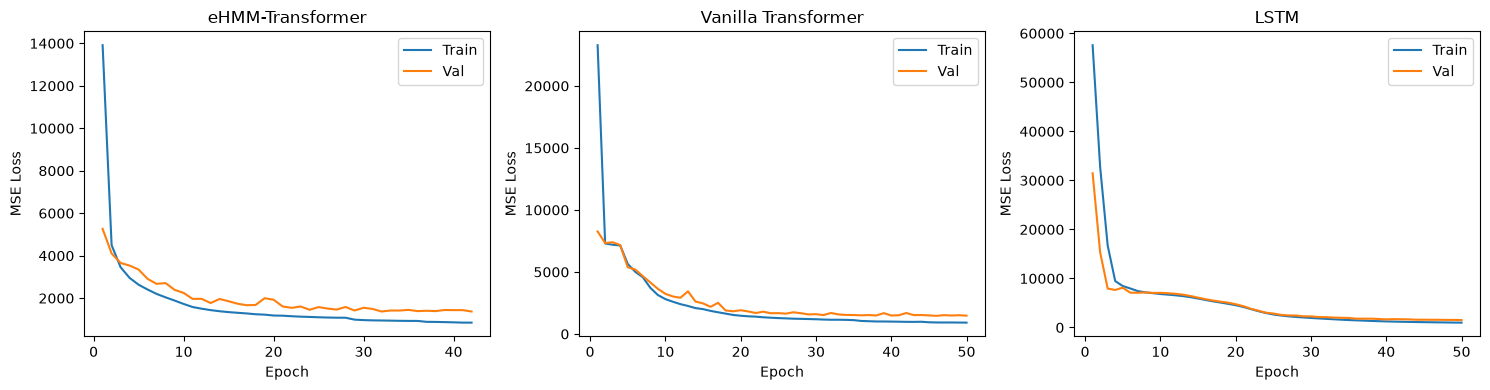

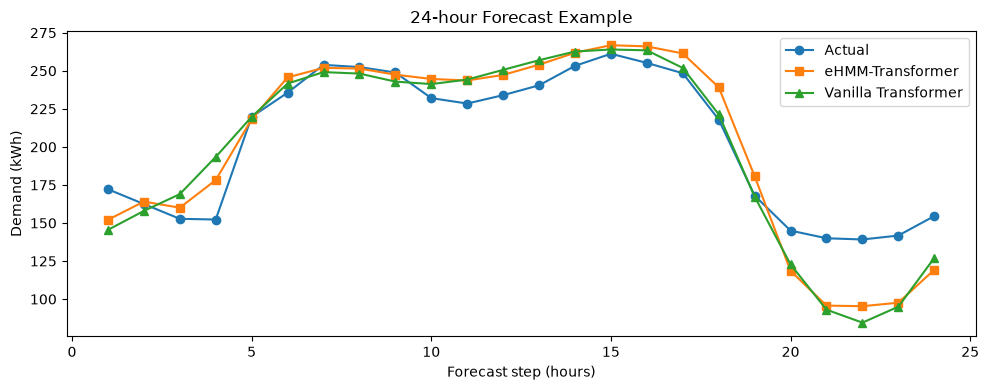

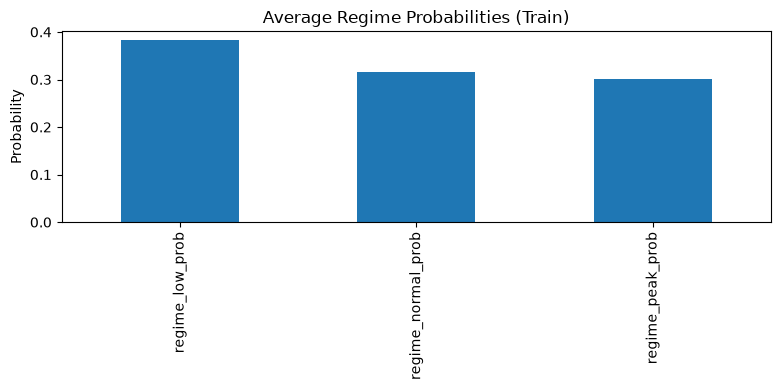

Saved:
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/metrics.csv
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/ablation_table.csv
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/hpo_trials.csv
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/best_hyperparameters.csv
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/figures/training_loss_curves.png
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/figures/prediction_plot.png
  /Users/huynguyen/Documents/UIT/5th/project_final/eHMM-Guided-Transformer-for-Electricity-Demand-Forecasting/outputs/figures/regime_distribution.png
  /

In [14]:
# Training loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, history) in zip(axes, [
    ("eHMM-Transformer", proposed_history),
    ("Vanilla Transformer", vanilla_history),
    ("LSTM", lstm_history),
]):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], label="Train")
    ax.plot(epochs, history["val_loss"], label="Val")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "training_loss_curves.png", dpi=150)
plt.show()

# 24-hour prediction example
prop_pred, prop_true = predict_loader(proposed_model, proposed_test_loader)
van_pred, van_true = predict_loader(vanilla_model, vanilla_test_loader)

idx = 0
horizon = CONFIG["forecast_horizon"]
steps = np.arange(1, horizon + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, prop_true[idx], label="Actual", marker="o")
ax.plot(steps, prop_pred[idx], label="eHMM-Transformer", marker="s")
ax.plot(steps, van_pred[idx], label="Vanilla Transformer", marker="^")
ax.set_xlabel("Forecast step (hours)")
ax.set_ylabel("Demand (kWh)")
ax.set_title("24-hour Forecast Example")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "prediction_plot.png", dpi=150)
plt.show()

# Regime distribution
fig, ax = plt.subplots(figsize=(8, 4))
train_df[["regime_low_prob", "regime_normal_prob", "regime_peak_prob"]].mean().plot(kind="bar", ax=ax)
ax.set_title("Average Regime Probabilities (Train)")
ax.set_ylabel("Probability")
fig.tight_layout()
fig.savefig(FIG_DIR / "regime_distribution.png", dpi=150)
plt.show()

pd.DataFrame({
    "y_true": flatten_forecasts(prop_true),
    "ehmm_transformer": flatten_forecasts(prop_pred),
    "vanilla_transformer": flatten_forecasts(van_pred),
}).to_csv(PRED_DIR / "test_predictions.csv", index=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'metrics.csv'}")
print(f"  {OUTPUT_DIR / 'ablation_table.csv'}")
print(f"  {OUTPUT_DIR / 'hpo_trials.csv'}")
print(f"  {OUTPUT_DIR / 'best_hyperparameters.csv'}")
print(f"  {FIG_DIR / 'training_loss_curves.png'}")
print(f"  {FIG_DIR / 'prediction_plot.png'}")
print(f"  {FIG_DIR / 'regime_distribution.png'}")
print(f"  {PRED_DIR / 'test_predictions.csv'}")